# EXPLORATORIO
## U-Net 3D Denoising

Carga del modelo U-Net 3D pre-entrenado y aplicación sobre el mismo cubo para comparar con el resultado wavelet.

# 1. Importaciones y Configuración

In [1]:
import sys
sys.path.append('../../src')

from astropy.io import fits
import torch
import torch.nn.functional as F
from u_net_model import UNet3D, UNet3DWithPadCrop
import numpy as np
import os
import matplotlib.pyplot as plt
import astropy.units as u
from radio_beam import Beams, Beam
from astropy.convolution import convolve, convolve_fft
from spectral_cube import SpectralCube

mkdir -p failed for path /.matplotlib: [Errno 30] Read-only file system: '/.matplotlib'
Matplotlib created a temporary cache directory at /var/folders/2b/5tqr_dzn551f21glw27fr5t40000gn/T/matplotlib-1ohkc_2m because there was an issue with the default path (/.matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.
Matplotlib is building the font cache; this may take a moment.


In [2]:
if torch.backends.mps.is_available():
    device = torch.device('mps')
elif torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')

print(f'Dispositivo: {device}')

WEIGHTS_PATH = '../../weights/weights_best.pt'
DATA_DIR = '/Users/kuky/Documents/practica/Denoiser3D-IFU/data/mock_cubes'

Dispositivo: mps


# 2. Definición de funciones

In [3]:
TRAINING_TARGET_SHAPE = (48, 96, 96)

def load_unet(weights_path, device, target_shape=TRAINING_TARGET_SHAPE):
    """Load U-Net with the same target_shape used during training.
    
    Parameters
    ----------
    weights_path : str
        Path to the saved model weights (.pt file).
    device : torch.device
        Device to load the model onto.
    target_shape : tuple of int, optional
        Fixed (D, H, W) used during training. Must match the shape the model
        was trained with so that internal feature scales are consistent.
        
    Returns
    -------
    model : UNet3DWithPadCrop
        Loaded model in eval mode. The wrapper handles padding/cropping
        automatically, so any input shape smaller than target_shape is valid.
    """
    base_model = UNet3D(n_channels=1, filters=16) # Se llama a la función UNet3D con los parámetros por default.
    model = UNet3DWithPadCrop(base_model, target_shape=target_shape)
    state_dict = torch.load(weights_path, map_location=device, weights_only=True)
    model.load_state_dict(state_dict)
    model.to(device)
    model.eval()
    return model


def denoise_simple(cube, model, device):
    """Denoise by passing the cube directly through the bare UNet3D.
    
    The cube must already have the target shape expected by the network,
    so no padding, cropping, or interpolation is performed.
    
    Parameters
    ----------
    cube : np.ndarray
        Input cube (D, H, W) in original flux units.
        Must match the training target shape.
    model : UNet3DWithPadCrop
        Loaded model. Only ``model.unet`` (the inner UNet3D) is used.
    device : torch.device
    
    Returns
    -------
    np.ndarray
        Denoised cube in original flux units, same shape as input.
    """
    cube_mean, cube_std = cube.mean(), cube.std()
    normalized = (cube - cube_mean) / cube_std # Se normaliza los datos. Esto es necesario debido a que el modelo fue entrenado con datos normalizados.

    tensor_in = torch.tensor(
        normalized[np.newaxis, np.newaxis, ...], dtype=torch.float32
    ).to(device) # Se convierte el cubo en un tensor y se mueve al dispositivo.

    with torch.no_grad():
        out = model.unet(tensor_in)

    return ((out * cube_std) + cube_mean)[0, 0].cpu().numpy() 

# 3. Denoising

## 3.1. Ingreso del cubo

In [4]:
CUBE_NAME = 'isolated_AC5_N250/isolated_AC5_N250_noisy'


hdu = fits.open(os.path.join(DATA_DIR, f'{CUBE_NAME}.fits')) # Abrimos el cubo de entrada.
cube = np.nan_to_num(hdu[0].data[0].astype(np.float64), nan=0.0) # Convertimos los datos a float64 y reemplazamos los NaN por 0.
header = hdu[0].header # Header del cubo.

model = load_unet(WEIGHTS_PATH, device) # Cargamos el modelo.


## 3.2. Cálculo de SNR

In [6]:
# Vamos a calcular el peak SNR del cubo para verificar que esté dentro del rango de valores
# aceptables para el modelo.

rms_noise = np.std(cube[38:46])
peak_signal = np.max(cube)
peak_snr = peak_signal / rms_noise
print(f'Peak SNR: {peak_snr}')


Peak SNR: 12.407344109724765


In [7]:
denoised_simple = denoise_simple(cube, model, device) # Denoizamos el cubo.

print(f'[Simple]        shape={denoised_simple.shape}  '
      f'rango=[{denoised_simple.min():.4e}, {denoised_simple.max():.4e}]')

out_path = os.path.join(DATA_DIR, f'{CUBE_NAME}_unet_rawdenoise.fits')
hdu_out = fits.PrimaryHDU(denoised_simple, header=header)
hdu_out.writeto(out_path, overwrite=True, output_verify='fix')
print(f'Guardado: {out_path}')

[Simple]        shape=(48, 96, 96)  rango=[4.4705e-06, 5.7769e-04]
Guardado: /Users/kuky/Documents/practica/Denoiser3D-IFU/data/PointingB_calibrated_SourceA_Contsub_CubeLine_Natural_50kms_image_subcube1_subcube_unet_rawdenoise.fits


## 3.3. Convolución del Output de U-Net

Para realizar la convolución, primero debemos construir la gaussiana definida por canal. Los parámetros que se utilizan son los siguientes:
- BMAJ: (grados) FWHM del semieje mayor.
- BMIN: (grados) FWHM del semieje menor.
- BPA: (grados) ángulo de posición, medido desde el Norte hacia el Este.

**Importante:** BMAJ y BMIN son FWHM completos, no semiejes. Para una gaussiana se necesita convertir a $\sigma$ con $\sigma= FWHM / (2\sqrt{2ln2})$.

Para construir la gaussiana, vamos a utilizar las librerías `radio-beam` y `astropy`.

Primero calculamos el pixscale:

In [113]:
hdr = fits.getheader(os.path.join(DATA_DIR, f'{CUBE_NAME}.fits'))
cdelt2_deg = hdr['CDELT2']                    # grados/píxel (eje Dec)
pixscale = abs(cdelt2_deg) * 3600 * u.arcsec  # arcsec/píxel

pixscale

<Quantity 0.0258 arcsec>

In [114]:
raw_cube = SpectralCube.read(os.path.join(DATA_DIR, f'{CUBE_NAME}_unet_rawdenoise.fits')) # Cargamos el cubo de salida del modelo.

# --- Obtención de beams por canal --- #
original_hdu = fits.open(os.path.join(DATA_DIR, f'{CUBE_NAME}.fits')) # Leemos el cubo original.
beams = Beams.from_fits_bintable(original_hdu[1]) # Obtenemos los beams del cubo original.

data_out = np.empty(raw_cube.shape, dtype=np.float64) # Creamos un array para almacenar los datos de salida.

for i in range(raw_cube.shape[0]):
    plane = raw_cube.unmasked_data[i,:,:].value
    kernel = beams[i].as_kernel(pixscale)
    data_out[i] = convolve(
        plane, kernel,
        normalize_kernel=True,
        boundary='extend',
        )

final_hdu = fits.PrimaryHDU(data=data_out, header=original_hdu[0].header)

with fits.open(os.path.join(DATA_DIR, f'{CUBE_NAME}.fits')) as hdul_in:
    hdul_out = fits.HDUList([final_hdu])
    for ext in hdul_in[1:]:
        if ext.name == 'BEAMS':
            hdul_out.append(ext)
    hdul_out.writeto(os.path.join(DATA_DIR, f'{CUBE_NAME}_convolved.fits'), overwrite=True)


## 3.4. Testing para comprobar la correcta realización del procedimiento de convolución

Para comprobar si la convolución que estamos realizando la estamos haciendo bien, tenemos este caso. Por un lado, se tiene una imagen generada por CASA, y su PSF en otra imagen adjunta. La primera imagen tiene su beam asociado en el header. Debemos generar el kernel con ese beam, y compararlo con la PSF. Si son similares, significa que el procedimiento se está realizando de forma correcta.

In [22]:
# -- Obtención del kernel -- #
hdr = fits.getheader(os.path.join(DATA_DIR, 'ALMA_test_convolution' ,'SimulatedImage.image_fits.fits'))
cdelt2_deg = hdr['CDELT2']                    # grados/píxel (eje Dec)
pixscale = abs(cdelt2_deg) * 3600 * u.arcsec  # arcsec/píxel

print("pixscale:", pixscale)

image_cube = fits.open(os.path.join(DATA_DIR, 'ALMA_test_convolution' ,'SimulatedImage.image_fits.fits')) 
beam = Beam.from_fits_header(image_cube[0].header)

kernel = beam.as_kernel(pixscale)

pixscale: 0.0100000000000008 arcsec


In [23]:
# -- Obtención de la PSF -- #
psf_hdu = fits.open(os.path.join(DATA_DIR, 'ALMA_test_convolution', 'SimulatedImage.psf_fits.fits'))
psf_data = psf_hdu[0].data[0, 0, :, :]  # quitar ejes Stokes y Freq si aplica

In [24]:
kernel_arr = kernel.array # Se obtiene el array del kernel
kernel_peak = kernel_arr / kernel_arr.max() # Se normaliza el kernel

cy, cx = psf_data.shape[0] // 2, psf_data.shape[1] // 2 # Se obtiene el centro del kernel y la PSF
ky, kx = kernel_arr.shape[0] // 2, kernel_arr.shape[1] // 2
psf_crop = psf_data[cy - ky : cy + ky + 1, cx - kx : cx + kx + 1] # Se recorta la PSF para que tenga el mismo tamaño que el kernel

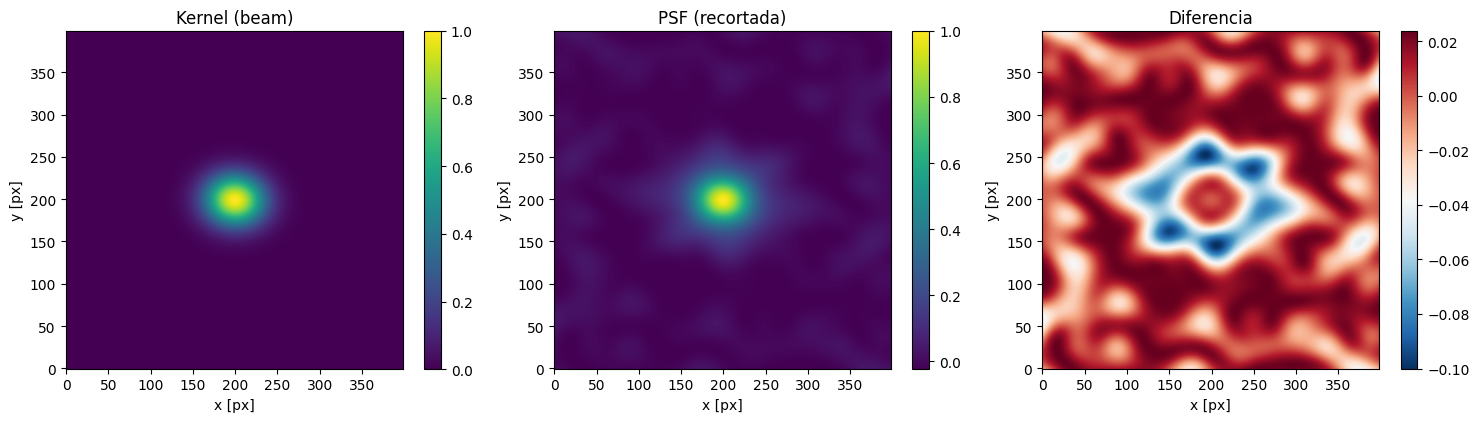

In [25]:
# -- Visualización de comparación -- #

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

im0 = axes[0].imshow(kernel_peak, origin='lower', cmap='viridis')
axes[0].set_title('Kernel (beam)')
fig.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(psf_crop, origin='lower', cmap='viridis')
axes[1].set_title('PSF (recortada)')
fig.colorbar(im1, ax=axes[1])

im2 = axes[2].imshow(kernel_peak - psf_crop, origin='lower', cmap='RdBu_r')
axes[2].set_title('Diferencia')
fig.colorbar(im2, ax=axes[2])

for ax in axes:
    ax.set_xlabel('x [px]')
    ax.set_ylabel('y [px]')
plt.tight_layout()

Perfecto, es básicamente lo mismo, por lo que significa que estamos generando de forma correcta el kernel.

# 4. Procedimiento en los 3 cubos de prueba

In [8]:
model = load_unet(WEIGHTS_PATH, device) # Cargamos el modelo.

POINTINGB = 'PointingB_calibrated_SourceA_Contsub_CubeLine_Natural_50kms_image_subcube1_subcube'
CONDOR06LD = 'CONDOR06LD_spw27_18kms_r05_subcube1'
CONDOR01COMB = 'CONDOR01COMB_CO32_15kms_r05._subcube1'

## 4.1. Pointing B

In [9]:
## -- Nombre del Cubo -- ##
CUBE_NAME = 'PointingB_calibrated_SourceA_Contsub_CubeLine_Natural_50kms_image_subcube1_subcube'

## -- Carga del cubo -- ##
hdu = fits.open(os.path.join(DATA_DIR, f'{CUBE_NAME}.fits')) # Abrimos el cubo de entrada.
cube = np.nan_to_num(hdu[0].data[0].astype(np.float64), nan=0.0) # Convertimos los datos a float64 y reemplazamos los NaN por 0.
header = hdu[0].header # Header del cubo.


## -- Cálculo de SNR -- ##
rms_noise = np.std(cube[0:22])
peak_signal = np.max(cube)
peak_snr = peak_signal / rms_noise
print(f'Peak SNR: {peak_snr}')

## -- Raw Denoising -- ##
denoised_simple = denoise_simple(cube, model, device) # Denoizamos el cubo.

print(f'[Simple]        shape={denoised_simple.shape}  '
      f'rango=[{denoised_simple.min():.4e}, {denoised_simple.max():.4e}]')

out_path = os.path.join(DATA_DIR, f'{CUBE_NAME}_unet_rawdenoise.fits')
hdu_out = fits.PrimaryHDU(denoised_simple, header=header)
hdu_out.writeto(out_path, overwrite=True, output_verify='fix')
print(f'Guardado: {out_path}')

## -- Convolución -- ##
# - Pixscale - #
hdr = fits.getheader(os.path.join(DATA_DIR, f'{CUBE_NAME}.fits'))
cdelt2_deg = hdr['CDELT2']                    # grados/píxel (eje Dec)
pixscale = abs(cdelt2_deg) * 3600 * u.arcsec  # arcsec/píxel

print("pixscale:", pixscale)

# - Carga del cubo Raw Denoised - #
raw_cube = SpectralCube.read(os.path.join(DATA_DIR, f'{CUBE_NAME}_unet_rawdenoise.fits')) # Cargamos el cubo de salida del modelo.

# - Obtención de beams por canal - #
original_hdu = fits.open(os.path.join(DATA_DIR, f'{CUBE_NAME}.fits')) # Leemos el cubo original.
beams = Beams.from_fits_bintable(original_hdu[1]) # Obtenemos los beams del cubo original.

data_out = np.empty(raw_cube.shape, dtype=np.float64) # Creamos un array para almacenar los datos de salida.

for i in range(raw_cube.shape[0]):
    plane = raw_cube.unmasked_data[i,:,:].value
    kernel = beams[i].as_kernel(pixscale)
    data_out[i] = convolve(
        plane, kernel,
        normalize_kernel=True,
        boundary='extend',
        )

final_hdu = fits.PrimaryHDU(data=data_out, header=original_hdu[0].header)

with fits.open(os.path.join(DATA_DIR, f'{CUBE_NAME}.fits')) as hdul_in:
    hdul_out = fits.HDUList([final_hdu])
    for ext in hdul_in[1:]:
        if ext.name == 'BEAMS':
            hdul_out.append(ext)
    hdul_out.writeto(os.path.join(DATA_DIR, f'{CUBE_NAME}_convolved.fits'), overwrite=True)

Peak SNR: 14.23531928619677
[Simple]        shape=(48, 96, 96)  rango=[4.4705e-06, 5.7769e-04]
Guardado: /Users/kuky/Documents/practica/Denoiser3D-IFU/data/PointingB_calibrated_SourceA_Contsub_CubeLine_Natural_50kms_image_subcube1_subcube_unet_rawdenoise.fits
pixscale: 0.0258000000000012 arcsec


## 4.1.1. Versión negativa

In [ ]:
## -- Carga del cubo -- ##
hdu = fits.open(os.path.join(DATA_DIR, f'{CUBE_NAME}.fits')) # Abrimos el cubo de entrada.
cube = np.nan_to_num(hdu[0].data[0].astype(np.float64), nan=0.0) # Convertimos los datos a float64 y reemplazamos los NaN por 0.
cube = cube * (-1)
header = hdu[0].header # Header del cubo.


## -- Raw Denoising -- ##
denoised_simple = denoise_simple(cube, model, device) # Denoizamos el cubo.

print(f'[Simple]        shape={denoised_simple.shape}  '
      f'rango=[{denoised_simple.min():.4e}, {denoised_simple.max():.4e}]')

out_path = os.path.join(DATA_DIR, f'{CUBE_NAME}_unet_rawdenoise_negative.fits')
hdu_out = fits.PrimaryHDU(denoised_simple, header=header)
hdu_out.writeto(out_path, overwrite=True, output_verify='fix')
print(f'Guardado: {out_path}')

## -- Convolución -- ##
# - Pixscale - #
hdr = fits.getheader(os.path.join(DATA_DIR, f'{CUBE_NAME}.fits'))
cdelt2_deg = hdr['CDELT2']                    # grados/píxel (eje Dec)
pixscale = abs(cdelt2_deg) * 3600 * u.arcsec  # arcsec/píxel

print("pixscale:", pixscale)

# - Carga del cubo Raw Denoised - #
raw_cube = SpectralCube.read(os.path.join(DATA_DIR, f'{CUBE_NAME}_unet_rawdenoise_negative.fits')) # Cargamos el cubo de salida del modelo.

# - Obtención de beams por canal - #
original_hdu = fits.open(os.path.join(DATA_DIR, f'{CUBE_NAME}.fits')) # Leemos el cubo original.
beams = Beams.from_fits_bintable(original_hdu[1]) # Obtenemos los beams del cubo original.

data_out = np.empty(raw_cube.shape, dtype=np.float64) # Creamos un array para almacenar los datos de salida.

for i in range(raw_cube.shape[0]):
    plane = raw_cube.unmasked_data[i,:,:].value
    kernel = beams[i].as_kernel(pixscale)
    data_out[i] = convolve(
        plane, kernel,
        normalize_kernel=True,
        boundary='extend',
        )

final_hdu = fits.PrimaryHDU(data=data_out, header=original_hdu[0].header)

with fits.open(os.path.join(DATA_DIR, f'{CUBE_NAME}.fits')) as hdul_in:
    hdul_out = fits.HDUList([final_hdu])
    for ext in hdul_in[1:]:
        if ext.name == 'BEAMS':
            hdul_out.append(ext)
    hdul_out.writeto(os.path.join(DATA_DIR, f'{CUBE_NAME}_convolved_negative.fits'), overwrite=True)

[Simple]        shape=(48, 96, 96)  rango=[-8.4679e-06, 7.0899e-05]
Guardado: /Users/kuky/Documents/practica/Denoiser3D-IFU/data/PointingB_calibrated_SourceA_Contsub_CubeLine_Natural_50kms_image_subcube1_subcube_unet_rawdenoise_negative.fits
pixscale: 0.0258000000000012 arcsec


## 4.2. CONDOR06LD

In [10]:
## -- Nombre del Cubo -- ##
CUBE_NAME = 'CONDOR06LD_spw27_18kms_r05_subcube1'

## -- Carga del cubo -- ##
hdu = fits.open(os.path.join(DATA_DIR, f'{CUBE_NAME}.fits')) # Abrimos el cubo de entrada.
cube = np.nan_to_num(hdu[0].data[0].astype(np.float64), nan=0.0) # Convertimos los datos a float64 y reemplazamos los NaN por 0.
header = hdu[0].header # Header del cubo.

## -- Cálculo de SNR -- ##
rms_noise = np.std(cube[30:47])
peak_signal = np.max(cube)
peak_snr = peak_signal / rms_noise
print(f'Peak SNR: {peak_snr}')

## -- Raw Denoising -- ##
denoised_simple = denoise_simple(cube, model, device) # Denoizamos el cubo.

print(f'[Simple]        shape={denoised_simple.shape}  '
      f'rango=[{denoised_simple.min():.4e}, {denoised_simple.max():.4e}]')

out_path = os.path.join(DATA_DIR, f'{CUBE_NAME}_unet_rawdenoise.fits')
hdu_out = fits.PrimaryHDU(denoised_simple, header=header)
hdu_out.writeto(out_path, overwrite=True, output_verify='fix')
print(f'Guardado: {out_path}')

## -- Convolución -- ##
# - Pixscale - #
hdr = fits.getheader(os.path.join(DATA_DIR, f'{CUBE_NAME}.fits'))
cdelt2_deg = hdr['CDELT2']                    # grados/píxel (eje Dec)
pixscale = abs(cdelt2_deg) * 3600 * u.arcsec  # arcsec/píxel

print("pixscale:", pixscale)

# - Carga del cubo Raw Denoised - #
raw_cube = SpectralCube.read(os.path.join(DATA_DIR, f'{CUBE_NAME}_unet_rawdenoise.fits')) # Cargamos el cubo de salida del modelo.

# - Obtención de beams por canal - #
original_hdu = fits.open(os.path.join(DATA_DIR, f'{CUBE_NAME}.fits')) # Leemos el cubo original.
beams = Beams.from_fits_bintable(original_hdu[1]) # Obtenemos los beams del cubo original.

data_out = np.empty(raw_cube.shape, dtype=np.float64) # Creamos un array para almacenar los datos de salida.

for i in range(raw_cube.shape[0]):
    plane = raw_cube.unmasked_data[i,:,:].value
    kernel = beams[i].as_kernel(pixscale)
    data_out[i] = convolve(
        plane, kernel,
        normalize_kernel=True,
        boundary='extend',
        )

final_hdu = fits.PrimaryHDU(data=data_out, header=original_hdu[0].header)

with fits.open(os.path.join(DATA_DIR, f'{CUBE_NAME}.fits')) as hdul_in:
    hdul_out = fits.HDUList([final_hdu])
    for ext in hdul_in[1:]:
        if ext.name == 'BEAMS':
            hdul_out.append(ext)
    hdul_out.writeto(os.path.join(DATA_DIR, f'{CUBE_NAME}_convolved.fits'), overwrite=True)

Peak SNR: 10.441947316740436
[Simple]        shape=(48, 96, 96)  rango=[2.0238e-07, 5.8298e-04]
Guardado: /Users/kuky/Documents/practica/Denoiser3D-IFU/data/CONDOR06LD_spw27_18kms_r05_subcube1_unet_rawdenoise.fits
pixscale: 0.100000000000008 arcsec


## 4.2.1. Versión negativa

In [12]:
## -- Carga del cubo -- ##
hdu = fits.open(os.path.join(DATA_DIR, f'{CUBE_NAME}.fits')) # Abrimos el cubo de entrada.
cube = np.nan_to_num(hdu[0].data[0].astype(np.float64), nan=0.0) # Convertimos los datos a float64 y reemplazamos los NaN por 0.
cube = cube * (-1)
header = hdu[0].header # Header del cubo.


## -- Raw Denoising -- ##
denoised_simple = denoise_simple(cube, model, device) # Denoizamos el cubo.

print(f'[Simple]        shape={denoised_simple.shape}  '
      f'rango=[{denoised_simple.min():.4e}, {denoised_simple.max():.4e}]')

out_path = os.path.join(DATA_DIR, f'{CUBE_NAME}_unet_rawdenoise_negative.fits')
hdu_out = fits.PrimaryHDU(denoised_simple, header=header)
hdu_out.writeto(out_path, overwrite=True, output_verify='fix')
print(f'Guardado: {out_path}')

## -- Convolución -- ##
# - Pixscale - #
hdr = fits.getheader(os.path.join(DATA_DIR, f'{CUBE_NAME}.fits'))
cdelt2_deg = hdr['CDELT2']                    # grados/píxel (eje Dec)
pixscale = abs(cdelt2_deg) * 3600 * u.arcsec  # arcsec/píxel

print("pixscale:", pixscale)

# - Carga del cubo Raw Denoised - #
raw_cube = SpectralCube.read(os.path.join(DATA_DIR, f'{CUBE_NAME}_unet_rawdenoise_negative.fits')) # Cargamos el cubo de salida del modelo.

# - Obtención de beams por canal - #
original_hdu = fits.open(os.path.join(DATA_DIR, f'{CUBE_NAME}.fits')) # Leemos el cubo original.
beams = Beams.from_fits_bintable(original_hdu[1]) # Obtenemos los beams del cubo original.

data_out = np.empty(raw_cube.shape, dtype=np.float64) # Creamos un array para almacenar los datos de salida.

for i in range(raw_cube.shape[0]):
    plane = raw_cube.unmasked_data[i,:,:].value
    kernel = beams[i].as_kernel(pixscale)
    data_out[i] = convolve(
        plane, kernel,
        normalize_kernel=True,
        boundary='extend',
        )

final_hdu = fits.PrimaryHDU(data=data_out, header=original_hdu[0].header)

with fits.open(os.path.join(DATA_DIR, f'{CUBE_NAME}.fits')) as hdul_in:
    hdul_out = fits.HDUList([final_hdu])
    for ext in hdul_in[1:]:
        if ext.name == 'BEAMS':
            hdul_out.append(ext)
    hdul_out.writeto(os.path.join(DATA_DIR, f'{CUBE_NAME}_convolved_negative.fits'), overwrite=True)

[Simple]        shape=(48, 96, 96)  rango=[-5.2837e-06, 2.9986e-05]
Guardado: /Users/kuky/Documents/practica/Denoiser3D-IFU/data/CONDOR06LD_spw27_18kms_r05_subcube1_unet_rawdenoise_negative.fits
pixscale: 0.100000000000008 arcsec


## 4.3. CONDOR01COMB

In [11]:
## -- Nombre del Cubo -- ##
CUBE_NAME = 'CONDOR01COMB_CO32_15kms_r05._subcube1'

## -- Carga del cubo -- ##
hdu = fits.open(os.path.join(DATA_DIR, f'{CUBE_NAME}.fits')) # Abrimos el cubo de entrada.
cube = np.nan_to_num(hdu[0].data[0].astype(np.float64), nan=0.0) # Convertimos los datos a float64 y reemplazamos los NaN por 0.
header = hdu[0].header # Header del cubo.

## -- Cálculo de SNR -- ##
rms_noise = np.std(cube[42:47])
peak_signal = np.max(cube)
peak_snr = peak_signal / rms_noise
print(f'Peak SNR: {peak_snr}')

## -- Raw Denoising -- ##
denoised_simple = denoise_simple(cube, model, device) # Denoizamos el cubo.

print(f'[Simple]        shape={denoised_simple.shape}  '
      f'rango=[{denoised_simple.min():.4e}, {denoised_simple.max():.4e}]')

out_path = os.path.join(DATA_DIR, f'{CUBE_NAME}_unet_rawdenoise.fits')
hdu_out = fits.PrimaryHDU(denoised_simple, header=header)
hdu_out.writeto(out_path, overwrite=True, output_verify='fix')
print(f'Guardado: {out_path}')

# - Carga del cubo Raw Denoised - #
raw_cube = SpectralCube.read(os.path.join(DATA_DIR, f'{CUBE_NAME}_unet_rawdenoise.fits')) # Cargamos el cubo de salida del modelo.

# - Obtención de beams por canal - #
original_hdu = fits.open(os.path.join(DATA_DIR, f'{CUBE_NAME}.fits')) # Leemos el cubo original.
beams = Beams.from_fits_bintable(original_hdu[1]) # Obtenemos los beams del cubo original.

data_out = np.empty(raw_cube.shape, dtype=np.float64) # Creamos un array para almacenar los datos de salida.

for i in range(raw_cube.shape[0]):
    plane = raw_cube.unmasked_data[i,:,:].value
    kernel = beams[i].as_kernel(pixscale)
    data_out[i] = convolve(
        plane, kernel,
        normalize_kernel=True,
        boundary='extend',
        )

final_hdu = fits.PrimaryHDU(data=data_out, header=original_hdu[0].header)

with fits.open(os.path.join(DATA_DIR, f'{CUBE_NAME}.fits')) as hdul_in:
    hdul_out = fits.HDUList([final_hdu])
    for ext in hdul_in[1:]:
        if ext.name == 'BEAMS':
            hdul_out.append(ext)
    hdul_out.writeto(os.path.join(DATA_DIR, f'{CUBE_NAME}_convolved.fits'), overwrite=True)

Peak SNR: 28.36564898889218
[Simple]        shape=(48, 96, 96)  rango=[1.8924e-05, 1.7356e-03]
Guardado: /Users/kuky/Documents/practica/Denoiser3D-IFU/data/CONDOR01COMB_CO32_15kms_r05._subcube1_unet_rawdenoise.fits


## 4.3.1. Versión negativa

In [16]:
## -- Carga del cubo -- ##
hdu = fits.open(os.path.join(DATA_DIR, f'{CUBE_NAME}.fits')) # Abrimos el cubo de entrada.
cube = np.nan_to_num(hdu[0].data[0].astype(np.float64), nan=0.0) # Convertimos los datos a float64 y reemplazamos los NaN por 0.
cube = cube * (-1)
header = hdu[0].header # Header del cubo.


## -- Raw Denoising -- ##
denoised_simple = denoise_simple(cube, model, device) # Denoizamos el cubo.

print(f'[Simple]        shape={denoised_simple.shape}  '
      f'rango=[{denoised_simple.min():.4e}, {denoised_simple.max():.4e}]')

out_path = os.path.join(DATA_DIR, f'{CUBE_NAME}_unet_rawdenoise_negative.fits')
hdu_out = fits.PrimaryHDU(denoised_simple, header=header)
hdu_out.writeto(out_path, overwrite=True, output_verify='fix')
print(f'Guardado: {out_path}')

## -- Convolución -- ##
# - Pixscale - #
hdr = fits.getheader(os.path.join(DATA_DIR, f'{CUBE_NAME}.fits'))
cdelt2_deg = hdr['CDELT2']                    # grados/píxel (eje Dec)
pixscale = abs(cdelt2_deg) * 3600 * u.arcsec  # arcsec/píxel

print("pixscale:", pixscale)

# - Carga del cubo Raw Denoised - #
raw_cube = SpectralCube.read(os.path.join(DATA_DIR, f'{CUBE_NAME}_unet_rawdenoise_negative.fits')) # Cargamos el cubo de salida del modelo.

# - Obtención de beams por canal - #
original_hdu = fits.open(os.path.join(DATA_DIR, f'{CUBE_NAME}.fits')) # Leemos el cubo original.
beams = Beams.from_fits_bintable(original_hdu[1]) # Obtenemos los beams del cubo original.

data_out = np.empty(raw_cube.shape, dtype=np.float64) # Creamos un array para almacenar los datos de salida.

for i in range(raw_cube.shape[0]):
    plane = raw_cube.unmasked_data[i,:,:].value
    kernel = beams[i].as_kernel(pixscale)
    data_out[i] = convolve(
        plane, kernel,
        normalize_kernel=True,
        boundary='extend',
        )

final_hdu = fits.PrimaryHDU(data=data_out, header=original_hdu[0].header)

with fits.open(os.path.join(DATA_DIR, f'{CUBE_NAME}.fits')) as hdul_in:
    hdul_out = fits.HDUList([final_hdu])
    for ext in hdul_in[1:]:
        if ext.name == 'BEAMS':
            hdul_out.append(ext)
    hdul_out.writeto(os.path.join(DATA_DIR, f'{CUBE_NAME}_convolved_negative.fits'), overwrite=True)

[Simple]        shape=(48, 96, 96)  rango=[-3.3681e-05, 2.6945e-05]
Guardado: /Users/kuky/Documents/practica/Denoiser3D-IFU/data/CONDOR01COMB_CO32_15kms_r05._subcube1_unet_rawdenoise_negative.fits
pixscale: 0.039999999999996004 arcsec


# ANEXO. Estudio en profundidad de U-Net

Revisemos en detalle las funciones que estamos utilizando:
```
def load_unet(weights_path, device, target_shape=TRAINING_TARGET_SHAPE, n_channels_unet=1, filters_unet=16):

    base_model = UNet3D(n_channels=n_channels_unet, filters=filters_unet)
    model = UNet3DWithPadCrop(base_model, target_shape=target_shape)
    state_dict = torch.load(weights_path, map_location=device, weights_only=True)
    model.load_state_dict(state_dict)
    model.to(device)
    model.eval()
    return model
```

Como se puede observar, utilizamos dos funciones del archivo `u_net_model.py`, llamadas `UNet3D` y `UNet3DWithPadCrop`.

`UNet3D`
Es una implementación de la arquitectura U-Net, estrcucturada de la siguiente manera:
- **Encoder:** 5 niveles de downsampling con incremento de profundidad de canal.
- **Bottleneck:** Representación más profunda con profundidad de canal máxima.
- **Decoder:** 4 niveles de upsampling con conexiones de salto desde el encoder.
- **Output:** Representación de 1 canal representando al cubo sin ruido.

Tiene las siguientes elecciones de diseño extra:
- **Reflective padding:** Maneja las condiciones de borde naturalmente.
- **LeakyReLU activation:** Previene neuronas muertas y maneja los valores negativos.
- **Skip connections:** Preserva los detalles finos perdidos durante el downsampling.
- **No bias terms:** Reduce el overfitting para casos con poca data de entrenamiento.

Tiene los siguientes parámetros:
- `n_channels`: (int) Número de canales de input (típicamente es 1 para cubos espectrales únicos). Si quisiéramos pasarle al modelo, por ejemplo, dos cubos, siendo uno de señal y otro de varianza, ahí el valor sería 2.
- `filters`: (int : default 8) Número base de filtros convolucionales. Se doblan para cada nivel del encoder. Esto controla la capacidad (complejidad) de la red. Un valor más alto le da a la red más capacidad de aprender patrones complejos, pero también aumenta significativamente la memoria y el tiempo de cómputo.
- `pad`: (int) Tamaño del kernel convolucional para operaciones convolucionales (todas las convoluciones de la red usan kernels de tamaño pad x pad x pad). Si `pad=3`, entonces cada neurona "ve" una vecindad de 3 vóxeles en cada dirección. Es el valor estándar, buen equilibrio entre campo receptivo y eficiencia.
Si `pad=5`, el campo receptivo es más amplio, captura correlaciones espaciales/espectrales más extendidas, pero es más costoso computacionalmente.
- `last_act`: (str : default 'identity') Define la función de activación final que se aplica a la salida de la red. Determina el rango de valores que peude producir el modelo

**Nota:** Todos estos parámetros, exceptuando `last_act` no pueden ser modificados sin la necesidad de re-entrenar la red, ya que esta fue entrenada usando los valor por default definidos en la función.
